In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
bon = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/bonneville.csv")
tda = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/dalles.csv")
jda = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/johnday.csv")
mcn = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/mcnary.csv")

In [5]:
bonsoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/bonneville-soc.csv")
tdasoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/dalles-soc.csv")
jdasoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/johnday-soc.csv")
mcnsoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/mcnary-soc.csv")

In [7]:
bon.rename(columns={"BON.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "BON.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "BON.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
tda.rename(columns={"TDA.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "TDA.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "TDA.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
jda.rename(columns={"JDA.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "JDA.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "JDA.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
mcn.rename(columns={"MCN.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "MCN.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "MCN.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)

In [9]:
bonsoc.rename(columns={"BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)
tdasoc.rename(columns={"TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)
jdasoc.rename(columns={"JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)
mcnsoc.rename(columns={"MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)

In [11]:
soc_df = (
    bonsoc[["Date Time", "soc_ft"]]
    .rename(columns={"soc_ft": "bon_soc_ft"})
    .merge(
        tdasoc[["Date Time", "soc_ft"]]
        .rename(columns={"soc_ft": "tda_soc_ft"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        jdasoc[["Date Time", "soc_ft"]]
        .rename(columns={"soc_ft": "jda_soc_ft"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        mcnsoc[["Date Time", "soc_ft"]]
        .rename(columns={"soc_ft": "mcn_soc_ft"}),
        on="Date Time",
        how="inner",
    )
)

In [13]:
bon = bon.bfill()
tda = tda.bfill()
jda = jda.bfill()
mcn = mcn.bfill()

In [15]:
dfs = {
    "bon": bon,
    "tda": tda,
    "jda": jda,
    "mcn": mcn,
}

## System Parameters

In [18]:
def flow_limits(dfs, flow_col="outflow (kcfs)"):
    rows = []
    for name, df in dfs.items():
        x = df[flow_col].dropna()
        ramp = x.diff().dropna()
        rows.append({"unit": name, "min_flow_kcfs": x.min(), "max_flow_kcfs": x.max(), "min_ramp_kcfs_per_hr": ramp.min(), "max_ramp_kcfs_per_hr": ramp.max()})
    return pd.DataFrame(rows)

In [20]:
dfs = {"bon": bon, "tda": tda, "jda": jda, "mcn": mcn}
limits = flow_limits(dfs, flow_col="outflow (kcfs)")
print(limits)

  unit  min_flow_kcfs  max_flow_kcfs  min_ramp_kcfs_per_hr  \
0  bon           29.0          260.0                -120.6   
1  tda           23.4          268.3                -118.1   
2  jda           47.5          265.4                -133.7   
3  mcn            0.0          230.8                 -94.6   

   max_ramp_kcfs_per_hr  
0                  68.7  
1                 110.2  
2                 135.0  
3                  94.6  


## Hydrograph

In [23]:
flow_dfs = [
    df[["Date Time", "inflow (kcfs)"]]
      .rename(columns={"inflow (kcfs)": f"{name}_inflow_kcfs"})
    for name, df in dfs.items()
]

hydrograph_df = (
    bon[["Date Time", "inflow (kcfs)"]]
    .rename(columns={"inflow (kcfs)": "bon_inflow_kcfs"})
    .merge(
        tda[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "tda_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        jda[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "jda_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        mcn[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "mcn_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
)

In [25]:
inflow_cols = [
    "bon_inflow_kcfs",
    "tda_inflow_kcfs",
    "jda_inflow_kcfs",
    "mcn_inflow_kcfs",
]

kcfs_to_m3s = 28.316846592

hydrograph_df["mean_inflow_m3s"] = hydrograph_df[inflow_cols].mean(axis=1) * kcfs_to_m3s

hydrograph_df["Date Time"] = pd.to_datetime(hydrograph_df["Date Time"])

hydrograph_df = hydrograph_df[hydrograph_df["Date Time"] >= "2018-01-01"].copy()

In [27]:
hydrograph_df.head()

,Date Time,bon_inflow_kcfs,tda_inflow_kcfs,jda_inflow_kcfs,mcn_inflow_kcfs,mean_inflow_m3s
4,2018-01-01 00:00:00,184.574,179.31,176.265,171.521,5038.062554
5,2018-01-01 01:00:00,184.574,179.31,176.265,171.521,5038.062554
6,2018-01-01 02:00:00,184.574,179.31,176.265,171.521,5038.062554
7,2018-01-01 03:00:00,184.574,179.31,176.265,171.521,5038.062554
8,2018-01-01 04:00:00,184.574,179.31,176.265,171.521,5038.062554


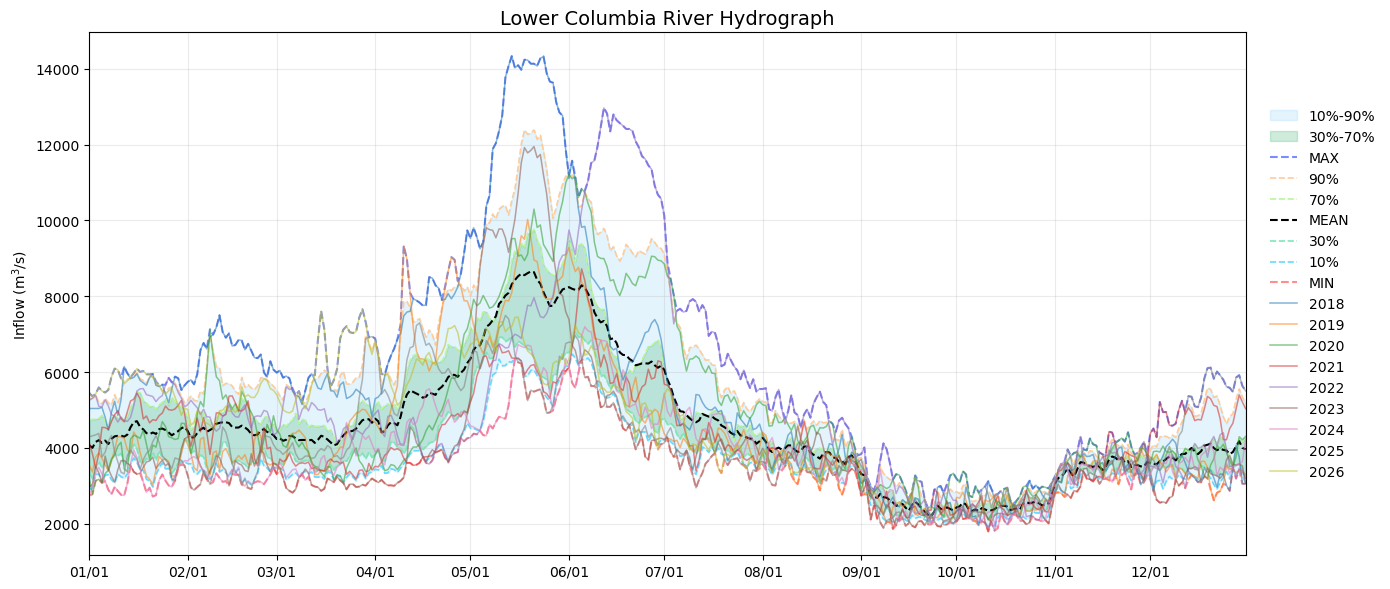

In [29]:
import matplotlib.dates as mdates

plot_individual_years = True # Toggle: True = show yearly lines, False = hide them

df = hydrograph_df.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"])
df = df[df["Date Time"] >= "2018-01-01"].copy()

df["year"] = df["Date Time"].dt.year
df["month"] = df["Date Time"].dt.month
df["day"] = df["Date Time"].dt.day

# Remove leap day so every year maps cleanly onto Jan 1-Dec 31
df = df[~((df["month"] == 2) & (df["day"] == 29))].copy()

# Use a common non-leap year for plotting all years on the same Jan-Dec axis
df["plot_date"] = pd.to_datetime(
    {
        "year": 2023,
        "month": df["month"],
        "day": df["day"],
    }
)

df = df.dropna(subset=["plot_date", "mean_inflow_m3s"])

# Daily average in case your data are hourly/subdaily
daily = (
    df.groupby(["year", "plot_date"], as_index=False)["mean_inflow_m3s"]
    .mean()
)

stats = (
    daily.groupby("plot_date")["mean_inflow_m3s"]
    .agg(
        min_flow="min",
        mean_flow="mean",
        max_flow="max",
        q10=lambda x: x.quantile(0.10),
        q30=lambda x: x.quantile(0.30),
        q70=lambda x: x.quantile(0.70),
        q90=lambda x: x.quantile(0.90),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Shaded quantile bands
ax.fill_between(
    stats["plot_date"],
    stats["q10"],
    stats["q90"],
    color="lightskyblue",
    alpha=0.22,
    label="10%-90%",
)

ax.fill_between(
    stats["plot_date"],
    stats["q30"],
    stats["q70"],
    color="mediumseagreen",
    alpha=0.25,
    label="30%-70%",
)

# Summary statistics
ax.plot(stats["plot_date"], stats["max_flow"], color="#7b8cff", linestyle="--", linewidth=1.5, label="MAX")
ax.plot(stats["plot_date"], stats["q90"], color="#ffcc99", linestyle="--", linewidth=1.2, label="90%")
ax.plot(stats["plot_date"], stats["q70"], color="#b9f59b", linestyle="--", linewidth=1.2, label="70%")
ax.plot(stats["plot_date"], stats["mean_flow"], color="black", linestyle="--", linewidth=1.5, label="MEAN")
ax.plot(stats["plot_date"], stats["q30"], color="#7ee6b8", linestyle="--", linewidth=1.2, label="30%")
ax.plot(stats["plot_date"], stats["q10"], color="#66d9ff", linestyle="--", linewidth=1.2, label="10%")
ax.plot(stats["plot_date"], stats["min_flow"], color="#ff8f8f", linestyle="--", linewidth=1.5, label="MIN")

# Optional individual yearly hydrographs
if plot_individual_years:
    for year, group in daily.groupby("year"):
        ax.plot(
            group["plot_date"],
            group["mean_inflow_m3s"],
            linewidth=1.1,
            alpha=0.55,
            label=str(year),
        )

ax.set_title("Lower Columbia River Hydrograph", fontsize=14)
ax.set_ylabel("Inflow (m$^3$/s)")
ax.set_xlabel("")

ax.set_xlim(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

ax.grid(True, alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout()
plt.show()

## Dry Season Analysis

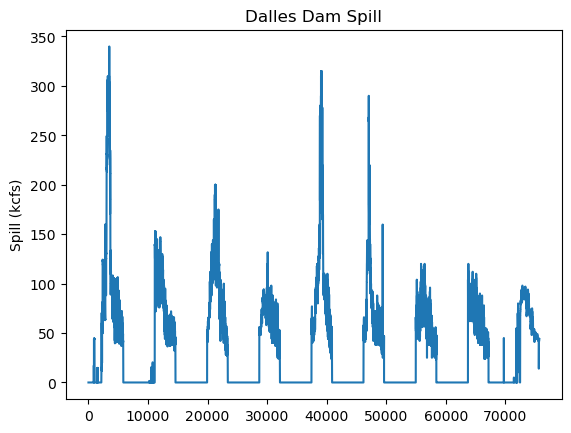

In [32]:
plt.plot(tda["spill (kcfs)"])
plt.title("Dalles Dam Spill")
plt.ylabel("Spill (kcfs)")
plt.show()

In [34]:
df = tda.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"])
df = df.sort_values("Date Time").copy()
df = df[df["Date Time"] >= "2018-01-01"]

spill_col = "spill (kcfs)"  

# Smooth the time series rolling window
window = 14*24  # active window
min_spill_days = 7*24

df["spill_days_rolling"] = (
    df[spill_col]
    .rolling(window=window, center=True, min_periods=1)
    .sum()
)

# Minimum days of spill 
df["spill_active_smooth"] = df["spill_days_rolling"] >= min_spill_days

# Define dry season as smoothed no-spill periods
df["dry_season"] = ~df["spill_active_smooth"]

In [36]:
df.head()

,Date Time,outflow (kcfs),inflow (kcfs),spill (kcfs),spill_days_rolling,spill_active_smooth,dry_season
4,2018-01-01 00:00:00,148.4,179.31,0.0,0.0,False,True
5,2018-01-01 01:00:00,123.9,179.31,0.0,0.0,False,True
6,2018-01-01 02:00:00,121.1,179.31,0.0,0.0,False,True
7,2018-01-01 03:00:00,121.9,179.31,0.0,0.0,False,True
8,2018-01-01 04:00:00,121.6,179.31,0.0,0.0,False,True


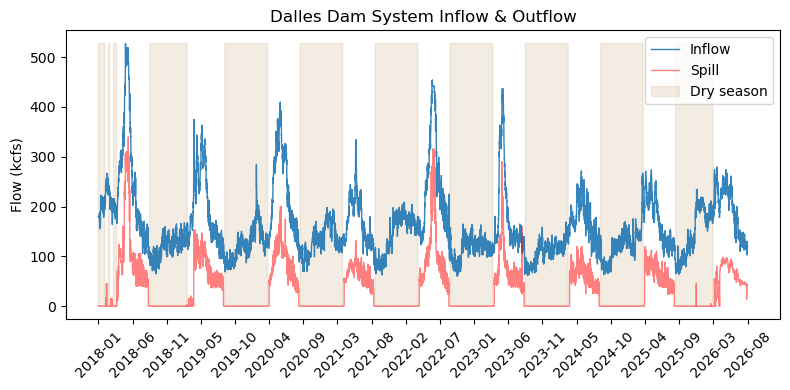

In [38]:
plt.figure(figsize=(8, 4))

tick_idx = np.linspace(0, len(df)-1, 20).astype(int)
#plt.plot(df["Date Time"], df["outflow (kcfs)"], linewidth=1, label="Gen. Outflow", color="green", alpha = 0.5)
plt.plot(df["Date Time"], df["inflow (kcfs)"], linewidth=1, label="Inflow", alpha = 0.9)
plt.plot(df["Date Time"], df[spill_col], linewidth=1, label="Spill", color = "red", alpha = 0.5)

plt.fill_between(df["Date Time"], 0, df["inflow (kcfs)"].max(), where=df["dry_season"], color="tan", alpha=0.25, label="Dry season")
plt.xticks(df["Date Time"].iloc[tick_idx], df["Date Time"].iloc[tick_idx].dt.strftime("%Y-%m"), rotation=45)

plt.ylabel("Flow (kcfs)")
plt.title("Dalles Dam System Inflow & Outflow")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
dry_blocks = df[df["dry_season"]].copy()
dry_blocks["block"] = (dry_blocks["Date Time"].diff() > pd.Timedelta(hours=1)).cumsum()
dry_ranges = dry_blocks.groupby("block")["Date Time"].agg(["min", "max"])
dry_ranges["days"] = (dry_ranges["max"] - dry_ranges["min"]).dt.days
dry_ranges = dry_ranges[dry_ranges["days"] >= 40]

print("Dry season training date ranges:")
for _, row in dry_ranges.iterrows(): print(f"{row['min'].strftime('%Y-%m-%d')} to {row['max'].strftime('%Y-%m-%d')}")

Dry season training date ranges:
2018-09-07 to 2018-11-26
2018-11-26 to 2019-03-08
2019-09-07 to 2020-04-03
2020-09-07 to 2021-04-03
2021-09-07 to 2022-04-03
2022-09-07 to 2022-11-09
2022-11-10 to 2023-04-03
2023-10-17 to 2024-03-18
2024-09-07 to 2025-04-03
2025-09-07 to 2026-03-08


### Rank Driest Year

In [43]:
flow_col = "mean_inflow_m3s"
df_flow = hydrograph_df.copy()
df_flow["Date Time"] = pd.to_datetime(df_flow["Date Time"])
dry_90_flow = df_flow[((df_flow["Date Time"].dt.month == 9) & (df_flow["Date Time"].dt.day >= 7)) | (df_flow["Date Time"].dt.month.isin([10, 11])) | ((df_flow["Date Time"].dt.month == 12) & (df_flow["Date Time"].dt.day <= 5))].copy()
dry_90_flow["dry_year"] = dry_90_flow["Date Time"].dt.year
dry_rank = dry_90_flow.groupby("dry_year")[flow_col].agg(["mean", "min", "max"]).sort_values("mean")
print(dry_rank)

                 mean          min          max
dry_year                                       
2023      2620.814712  1714.839913  4382.053248
2024      2721.669141  1751.984536  3851.954800
2019      2821.764159  1931.669086  4220.222469
2025      2856.971135  1774.149548  4309.710784
2021      2886.486209  1739.234876  5549.910793
2022      2917.205257  1680.116380  4584.476226
2018      2934.280913  1812.731251  4429.682184
2020      3208.168699  1928.681659  4896.180994


### Export Data

In [46]:
save_df = hydrograph_df[((hydrograph_df["Date Time"].dt.month == 9) & (hydrograph_df["Date Time"].dt.day >= 7)) | (hydrograph_df["Date Time"].dt.month.isin([10, 11])) | ((hydrograph_df["Date Time"].dt.month == 12) & (hydrograph_df["Date Time"].dt.day <= 5))].copy()
save_df = save_df.drop(columns="mean_inflow_m3s")

In [91]:
## Min Max Normalize data based on dry season flow min and max 
inflow_cols = [
    "bon_inflow_kcfs",
    "tda_inflow_kcfs",
    "jda_inflow_kcfs",
    "mcn_inflow_kcfs"
]

q_min = save_df[inflow_cols].min().min()
q_max = save_df[inflow_cols].max().max()

inflow_data_norm = save_df.copy()
# inflow_data_norm[inflow_cols] = (save_df[inflow_cols] - q_min) / (q_max - q_min)

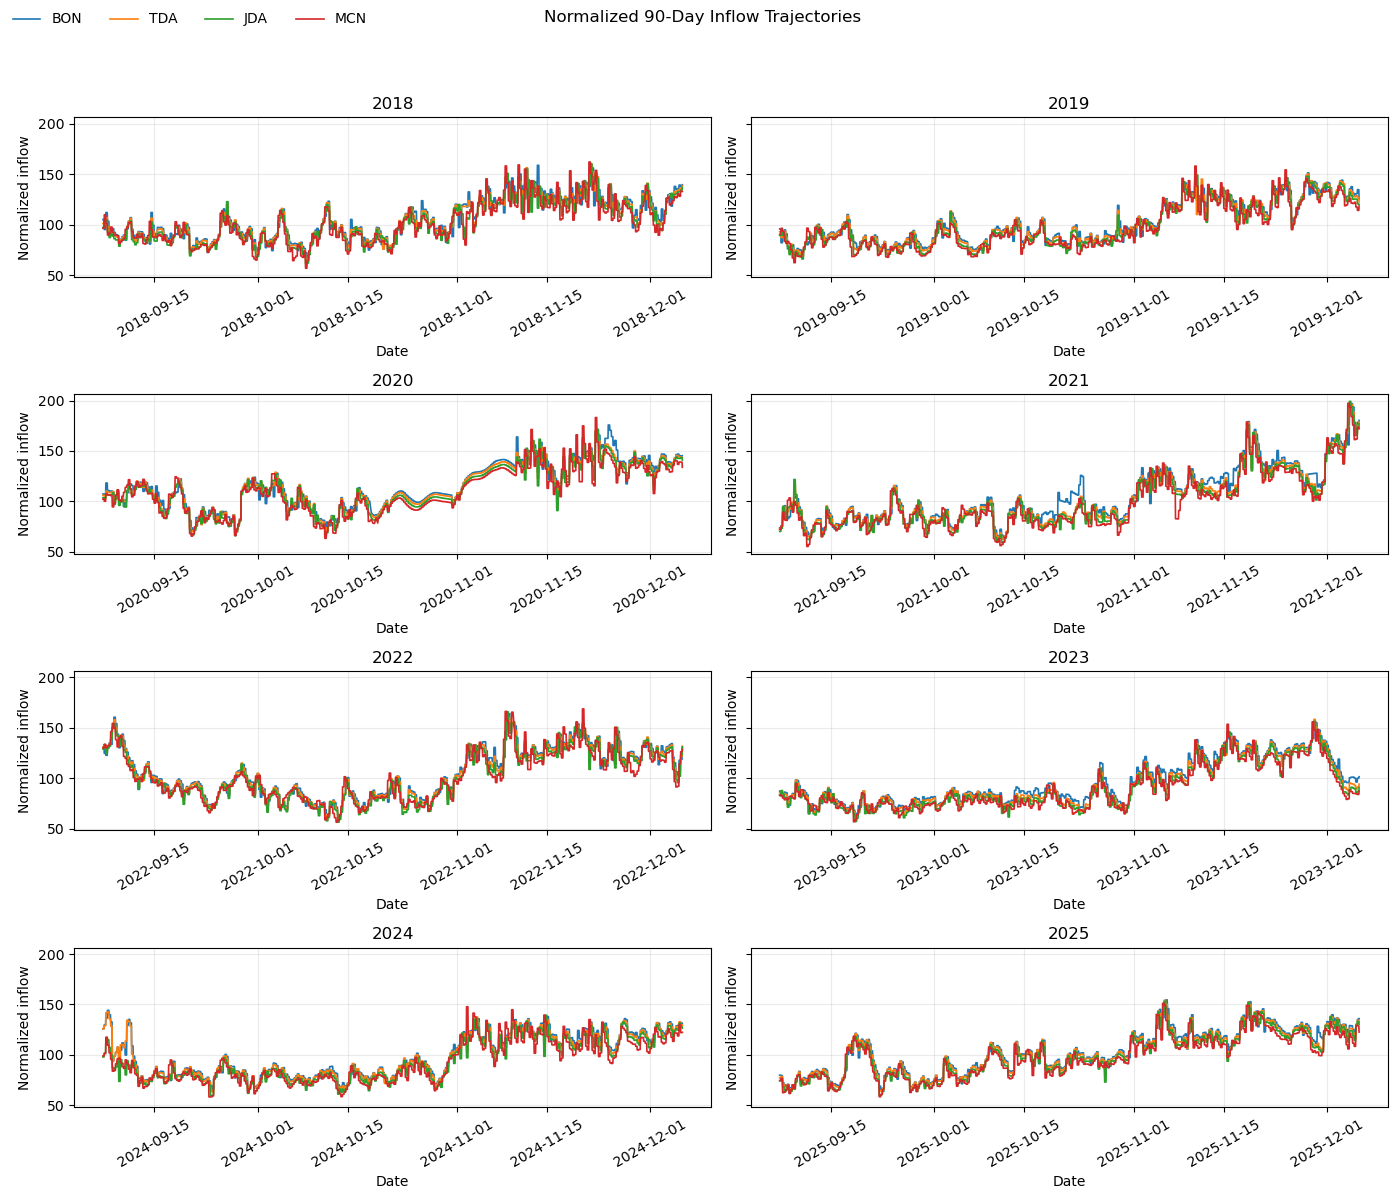

In [93]:
# Remove "_kcfs" from column names
inflow_data_norm = inflow_data_norm.rename(
    columns=lambda col: col.replace("_kcfs", "")
)

# Ensure Date Time is datetime
inflow_data_norm["Date Time"] = pd.to_datetime(
    inflow_data_norm["Date Time"]
)

inflow_cols = [
    "bon_inflow",
    "tda_inflow",
    "jda_inflow",
    "mcn_inflow"
]

years = sorted(inflow_data_norm["Date Time"].dt.year.unique())

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 12),
    sharey=True
)

axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = inflow_data_norm[
        inflow_data_norm["Date Time"].dt.year == year
    ]

    for col in inflow_cols:
        ax.plot(
            df_year["Date Time"],
            df_year[col],
            label=col.replace("_inflow", "").upper(),
            linewidth=1.2
        )

    ax.set_title(str(year))
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized inflow")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

# Use one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=4,
    frameon=False
)

fig.suptitle("Normalized 90-Day Inflow Trajectories", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [95]:
inflow_data_norm = inflow_data_norm.rename(columns={"Date Time": "datetime"})

### Interpolate Missing Data

In [98]:
len(inflow_data_norm) # should be 17280 

17224

In [100]:
years = range(2018, 2026)  # Complete seasons: 2018-2025

# Expected hourly timestamps
expected = pd.DatetimeIndex([]).append([pd.date_range(f"{y}-09-07", f"{y}-12-05 23:00", freq="h") for y in years])

In [102]:
expected

DatetimeIndex(['2018-09-07 00:00:00', '2018-09-07 01:00:00',
               '2018-09-07 02:00:00', '2018-09-07 03:00:00',
               '2018-09-07 04:00:00', '2018-09-07 05:00:00',
               '2018-09-07 06:00:00', '2018-09-07 07:00:00',
               '2018-09-07 08:00:00', '2018-09-07 09:00:00',
               ...
               '2025-12-05 14:00:00', '2025-12-05 15:00:00',
               '2025-12-05 16:00:00', '2025-12-05 17:00:00',
               '2025-12-05 18:00:00', '2025-12-05 19:00:00',
               '2025-12-05 20:00:00', '2025-12-05 21:00:00',
               '2025-12-05 22:00:00', '2025-12-05 23:00:00'],
              dtype='datetime64[ns]', length=17280, freq=None)

In [104]:
# Check missing timestamps
missing = expected.difference(inflow_data_norm["datetime"])
print("Missing hours by year:")
print(pd.Series(missing.year).value_counts().sort_index())

Missing hours by year:
2018     3
2019     1
2020    26
2021     4
2022    20
2023     2
Name: count, dtype: int64


In [106]:
# Remove duplicate timestamps and add missing rows
inflow_data_norm = (
    inflow_data_norm.groupby("datetime", as_index=False)[inflow_cols]
    .mean()
    .set_index("datetime")
    .reindex(expected)
)

In [108]:
print(inflow_data_norm.shape)     
print(inflow_data_norm.isna().sum())

(17280, 4)
bon_inflow    56
tda_inflow    56
jda_inflow    56
mcn_inflow    56
dtype: int64


In [116]:
# Interpolate data
inflow_data_norm[inflow_cols] = inflow_data_norm[inflow_cols].bfill()

inflow_data_norm = inflow_data_norm.reset_index(names="datetime")

print(inflow_data_norm.shape)     
print(inflow_data_norm.isna().sum())

(17280, 5)
datetime      0
bon_inflow    0
tda_inflow    0
jda_inflow    0
mcn_inflow    0
dtype: int64


In [118]:
inflow_data_norm.head()

,datetime,bon_inflow,tda_inflow,jda_inflow,mcn_inflow
0,2018-09-07 00:00:00,105.091,101.074,97.247,96.451
1,2018-09-07 01:00:00,105.091,101.074,97.247,96.451
2,2018-09-07 02:00:00,105.091,101.074,97.247,96.451
3,2018-09-07 03:00:00,105.091,101.074,97.247,96.451
4,2018-09-07 04:00:00,105.091,101.074,97.247,96.451


In [120]:
len(inflow_data_norm)

17280

In [122]:
inflow_data_norm.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/inflow.csv", index=False)

# SOC Reference 

In [72]:
## Merge on 90 Day Datetime Dataset 

soc_df = soc_df.rename(columns={"Date Time": "datetime"})

soc_df["datetime"] = pd.to_datetime(soc_df["datetime"])
inflow_data_norm["datetime"] = pd.to_datetime(inflow_data_norm["datetime"])

soc_df = soc_df.merge(
    inflow_data_norm[["datetime"]],
    on="datetime",
    how="inner"
)

In [74]:
# Min - Max normalization each column uniquely 
soc_cols = ["bon_soc_ft", "tda_soc_ft", "jda_soc_ft", "mcn_soc_ft"]

volume_max = {
    "bon_soc_ft": 1.5,
    "tda_soc_ft": 1.0,
    "jda_soc_ft": 1.5,
    "mcn_soc_ft": 4.0,
}

soc_df_norm = soc_df.copy()
soc_df_norm[soc_cols] = (soc_df_norm[soc_cols] - soc_df_norm[soc_cols].min()) / (soc_df_norm[soc_cols].max() - soc_df_norm[soc_cols].min())

for col in soc_cols:
    soc_df_norm[col] *= volume_max[col]

In [76]:
# Remove "_ft" from column names
soc_df_norm = soc_df_norm.rename(
    columns=lambda col: col.replace("_ft", "")
)

In [78]:
# Check missing timestamps
missing = expected.difference(soc_df_norm["datetime"])
print("Missing hours by year:")
print(pd.Series(missing.year).value_counts().sort_index())

Missing hours by year:
2018     4
2019     2
2020    31
2021     4
2022    26
2023     3
Name: count, dtype: int64


In [80]:
# Remove duplicate timestamps and add missing rows
soc_cols = ["bon_soc", "tda_soc", "jda_soc", "mcn_soc"]

soc_df_norm = (
    soc_df_norm.groupby("datetime", as_index=False)[soc_cols]
    .mean()
    .set_index("datetime")
    .reindex(expected)
)

In [82]:
# Interpolate data
soc_df_norm[soc_cols] = soc_df_norm[soc_cols].bfill()

soc_df_norm = soc_df_norm.reset_index(names="datetime")

print(soc_df_norm.shape)     
print(soc_df_norm.isna().sum())

(17280, 5)
datetime    0
bon_soc     0
tda_soc     0
jda_soc     0
mcn_soc     0
dtype: int64


In [84]:
soc_df_norm.head()

,datetime,bon_soc,tda_soc,jda_soc,mcn_soc
0,2018-09-07 00:00:00,1.021277,0.680782,0.219298,2.572491
1,2018-09-07 01:00:00,1.053191,0.680782,0.219298,2.795539
2,2018-09-07 02:00:00,1.053191,0.680782,0.263158,2.884758
3,2018-09-07 03:00:00,0.989362,0.680782,0.263158,3.018587
4,2018-09-07 04:00:00,1.053191,0.680782,0.263158,3.107807


In [86]:
soc_df_norm.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/soc.csv", index=False)

# Refit Regression 

In [ ]:
# Note (8/25/26): preliminary results have coefficients much different from the original diu framework
# Recommended fixes: start by keeping the dry season window the same, but maybe do it for the full period instead of 90 days
# Go back to the 6-hr intervals, not the hourly bfill ones, which is messing things up 
# Preserve the same min max normalization parameters used above to ensure that everything is on the same scale! 